In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mstats

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')



In [11]:
df= pd.read_csv("/kaggle/input/datasets/glakkoca/archive/StudentPerformanceFactors.csv")
print(f'Shape:{df.shape}')
df.head()

Shape:(6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [12]:
num_cols=df.select_dtypes(include=np.number).columns.tolist()
cat_cols=df.select_dtypes(include='object').columns.tolist()
print(f'numeric columns ({len(num_cols)}):{num_cols}')
print(f'categoric columns ({len(cat_cols)}):{cat_cols}')


numeric columns (7):['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']
categoric columns (13):['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


In [16]:
for col in cat_cols:
    if df[col].isnull().sum()>0:
        df[col]=df[col].fillna(df[col].mode()[0])
for col in num_cols:
    if df[col].isnull().sum()>0:
        df[col]=df[col].fillna(df[col].median())

print(f' the rest of missing value:{df.isnull().sum().sum()}')


 the rest of missing value:0


In [18]:
ordinal_maps = {
'Parental_Involvement'    : {'Low': 0, 'Medium': 1, 'High': 2},
    'Access_to_Resources'     : {'Low': 0, 'Medium': 1, 'High': 2},
    'Motivation_Level'        : {'Low': 0, 'Medium': 1, 'High': 2},
    'Family_Income'           : {'Low': 0, 'Medium': 1, 'High': 2},
    'Teacher_Quality'         : {'Low': 0, 'Medium': 1, 'High': 2},
    'Parental_Education_Level': {'High School': 0, 'College': 1, 'Postgraduate': 2},
    'Distance_from_Home'      : {'Near': 0, 'Moderate': 1, 'Far': 2},
    'Peer_Influence'          : {'Negative': 0, 'Neutral': 1, 'Positive': 2},
}

binary_maps = {
    'Extracurricular_Activities': {'No': 0, 'Yes': 1},
    'Internet_Access'           : {'No': 0, 'Yes': 1},
    'Learning_Disabilities'     : {'No': 0, 'Yes': 1},
    'School_Type'               : {'Public': 0, 'Private': 1},
    'Gender'                    : {'Male': 0, 'Female': 1},
}
for col,mapping in ordinal_maps.items():
     if col in df.columns:
         df[col]= df[col].map(mapping)
for col,mapping in binary_maps.items():
    if col in df.columns:
        df[col]=df[col].map(mapping)
print(' encoding is done')

 encoding is done


In [21]:
X= df.drop(columns=['Exam_Score'] )
Y= df['Exam_Score']
X_train, X_test, Y_train,Y_test= train_test_split(
    X,Y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')


Train: (5285, 19) | Test: (1322, 19)


In [26]:
num_feat= [ c for c in X_train.columns if X_train[c].dtype!= 'object']
for col in num_feat:
    X_train[col]= mstats.winsorize(X_train[col],limits=[0.01,0.01])
print('winsorize ok')
print(f'goal skewness: {Y_train.skew():.2f}')

winsorize ok
goal skewness: 1.71


In [28]:
def feat_eng(df_part):
    df_part= df_part.copy()
    df_part['study_consistency'] = df_part['Hours_Studied'] * df_part['Attendance']
    df_part['rest_ratio']        = df_part['Sleep_Hours'] / (df_part['Hours_Studied'] + 1)
    df_part['support_score']     = (
        df_part['Parental_Involvement'] +
        df_part['Access_to_Resources'] +
        df_part['Motivation_Level']
    )
    df_part['disadvantage_flag'] = (
        (df_part['Family_Income'] == 0) & (df_part['Access_to_Resources'] == 0)
    ).astype(int)
    return df_part

X_train = feat_eng(X_train)
X_test  = feat_eng(X_test)

print(f'Yeni shape: {X_train.shape}')
print(f'Yeni özellikler: study_consistency, rest_ratio, support_score, disadvantage_flag')

Yeni shape: (5285, 23)
Yeni özellikler: study_consistency, rest_ratio, support_score, disadvantage_flag


In [29]:
scaler= StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
print('Scaling ok')


Scaling ok


In [45]:
kf= KFold(n_splits=10, shuffle=True, random_state=42)

def evaluate_model(name,model, X_tr,X_te,Y_tr,Y_te,use_scaled=False):
    model.fit(X_tr,Y_tr)
    Y_pred= model.predict(X_te)
    mae= mean_absolute_error(Y_te,Y_pred)
    rmse=np.sqrt(mean_squared_error(Y_te,Y_pred))
    r2= r2_score(Y_te, Y_pred)

    cv_scores= cross_val_score(model, X_tr, Y_tr,cv=kf, scoring='r2')

    print(f'\n{"="*50}')
    print(f'{name}')
    print(f'{"="*50}')
    print(f'  MAE  : {mae:.4f}')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  R²   : {r2:.4f}')
    print(f'  CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

    return {
        'Model': name, 'MAE': mae, 'RMSE': rmse,
        'R²': r2, 'CV_R2': cv_scores.mean(),
        'fitted_model': model, 'Y_pred': Y_pred
    }

results = []
    

In [46]:
lr = LinearRegression()
lr_result = evaluate_model(
    'Linear Regression', lr,
    X_train_scaled, X_test_scaled, Y_train, Y_test
)
results.append(lr_result)


Linear Regression
  MAE  : 0.4499
  RMSE : 1.8004
  R²   : 0.7707
  CV R²: 0.7291 ± 0.1076


In [49]:
rf = RandomForestRegressor(
    n_estimators=300, max_depth=10,
    min_samples_split=5, min_samples_leaf=2,
    random_state=42, n_jobs=-1
)
rf_result = evaluate_model(
    'Random Forest', rf,
    X_train, X_test, Y_train, Y_test
)
results.append(rf_result)


Random Forest
  MAE  : 1.0577
  RMSE : 2.1195
  R²   : 0.6822
  CV R²: 0.6451 ± 0.1002


In [50]:
lgbm = LGBMRegressor(
    n_estimators=300, max_depth=8,
    learning_rate=0.05, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbose=-1
)
lgbm_result = evaluate_model(
    'LightGBM', lgbm,
    X_train, X_test, Y_train, Y_test
)
results.append(lgbm_result)


LightGBM
  MAE  : 0.7455
  RMSE : 1.9277
  R²   : 0.7371
  CV R²: 0.6989 ± 0.1046


In [51]:
xgb = XGBRegressor(
    n_estimators=300, max_depth=8,
    learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.1,
    reg_lambda=1.0, random_state=42,
    verbosity=0, n_jobs=-1
)
xgb_result = evaluate_model(
    'XGBoost', xgb,
    X_train, X_test, Y_train, Y_test
)
results.append(xgb_result)


XGBoost
  MAE  : 0.7818
  RMSE : 1.9896
  R²   : 0.7200
  CV R²: 0.6844 ± 0.0986


In [53]:
# LightGBM tuning
lgbm_params = {
    'n_estimators'     : [200, 400, 600],
    'max_depth'        : [4, 6, 8, -1],
    'learning_rate'    : [0.01, 0.03, 0.05, 0.1],
    'num_leaves'       : [15, 31, 63, 127],
    'subsample'        : [0.6, 0.8, 1.0],
    'colsample_bytree' : [0.6, 0.8, 1.0],
    'reg_alpha'        : [0, 0.1, 0.5, 1.0],
    'reg_lambda'       : [0, 0.1, 0.5, 1.0],
    'min_child_samples': [10, 20, 50],
}

lgbm_search = RandomizedSearchCV(
    LGBMRegressor(random_state=42, verbose=-1),
    param_distributions=lgbm_params,
    n_iter=50, cv=kf, scoring='r2',
    random_state=42, n_jobs=-1
)
lgbm_search.fit(X_train, Y_train)
print(f'LGBM En iyi CV R²: {lgbm_search.best_score_:.4f}')
print(f'LGBM Test R²     : {r2_score(Y_test, lgbm_search.predict(X_test)):.4f}')

# XGBoost tuning
xgb_params = {
    'n_estimators'    : [200, 400, 600],
    'max_depth'       : [4, 6, 8, 10],
    'learning_rate'   : [0.01, 0.03, 0.05, 0.1],
    'subsample'       : [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha'       : [0, 0.1, 0.5, 1.0],
    'reg_lambda'      : [0.5, 1.0, 2.0, 5.0],
    'min_child_weight': [1, 3, 5, 10],
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, verbosity=0, n_jobs=-1),
    param_distributions=xgb_params,
    n_iter=50, cv=kf, scoring='r2',
    random_state=42, n_jobs=-1
)
xgb_search.fit(X_train, Y_train)
print(f'\nXGB En iyi CV R²: {xgb_search.best_score_:.4f}')
print(f'XGB Test R²     : {r2_score(Y_test, xgb_search.predict(X_test)):.4f}')

LGBM En iyi CV R²: 0.7106
LGBM Test R²     : 0.7513

XGB En iyi CV R²: 0.7130
XGB Test R²     : 0.7536


In [57]:
estimators = [
    ('rf',   RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)),
    ('lgbm', lgbm_search.best_estimator_),
    ('xgb',  xgb_search.best_estimator_),
]

stack = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=5, n_jobs=-1
)
stack.fit(X_train, Y_train)
Y_pred_stack = stack.predict(X_test)

stack_result = {
    'Model': 'Stacking',
    'MAE' : mean_absolute_error(Y_test, Y_pred_stack),
    'RMSE': np.sqrt(mean_squared_error(Y_test, Y_pred_stack)),
    'R²'  : r2_score(Y_test, Y_pred_stack),
    'CV_R2': None,
    'fitted_model': stack,
    'Y_pred': Y_pred_stack
}
results.append(stack_result)

print(f'Stacking R²  : {stack_result["R²"]:.4f}')
print(f'Stacking MAE : {stack_result["MAE"]:.4f}')
print(f'Stacking RMSE: {stack_result["RMSE"]:.4f}')

Stacking R²  : 0.7554
Stacking MAE : 0.6107
Stacking RMSE: 1.8595


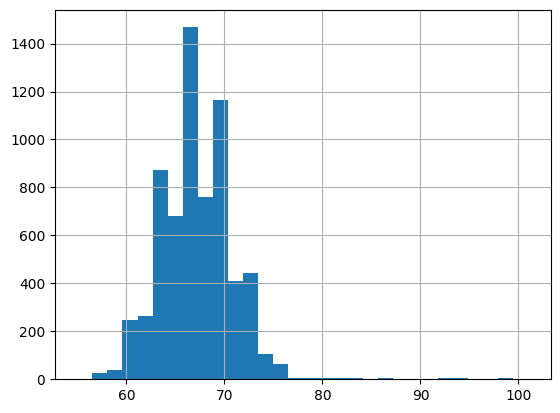

1.6448082853982677


In [59]:
import matplotlib.pyplot as plt
Y.hist(bins=30)
plt.show()
print(Y.skew())